# 05 · Feature Engineering — 02. Dataset para regresión salarial

Segundo notebook de la fase 05. Construye el dataset de entrada para el **modelo de regresión salarial**
a partir de `master_filtered.csv` (14.202 filas, 121 columnas) generado en 05_01.

## Objetivo

Producir un único archivo `regresion_dataset.csv` listo para entrenar modelos de regresión, donde:

- El target es `log_salary` (logaritmo del salario bruto anual).
- Las features de rendimiento están normalizadas a **per-90 minutos** (estándar en analítica futbolística).
- La redundancia identificada en 04_04 (27 pares con r≥0.95) se ha colapsado seleccionando representantes
  por cluster temático.
- Las variables categóricas (`position`, `country`, `season`, `nationality`) están codificadas one-hot.
- Se incluye la edad y su transformación cuadrática (`age²`) para capturar la curva salario-edad
  típica de la economía laboral (modelo de Mincer).

## Pasos del notebook

1. **Imports y carga** del dataset filtrado.
2. **Filtro del target**: solo filas con salario disponible.
3. **Construcción del target**: `log_salary = log(gross_annual_eur)`.
4. **Selección de features**: aplicación de los criterios derivados del clustering del 04_04
   sobre el dataset filtrado.
5. **Normalización per-90**: stats acumulables → tasa por 90 minutos.
6. **Features estructurales**: `age`, `age²`.
7. **Encoding de categóricas**: one-hot de `position`, `country`, `season`, `nationality` (top-15 + Otras).
8. **Tratamiento de NaN estructurales**: imputación + flag para `expectedGoals`, `expectedAssists`,
   `ballRecovery`.
9. **Validación final** del dataset.
10. **Guardado** en `data/modeling/regression/regresion_dataset.csv`.

---

## 1. Imports y carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

ROOT      = Path.cwd().parents[1]
FILTERED  = ROOT / 'data' / 'clean'     / 'master_filtered.csv'
OUT_DIR   = ROOT / 'data' / 'modeling' / 'regression'
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PATH  = OUT_DIR / 'regresion_dataset.csv'

df = pd.read_csv(FILTERED, dtype={'season': str})
print(f'Dataset cargado: {len(df):,} filas × {df.shape[1]} columnas')
df.head(3)

Dataset cargado: 14,202 filas × 121 columnas


,player,player_id,team,team_id,country,season,minutesPlayed,appearances,matchesStarted,rating,...,totwAppearances,touches,wasFouled,yellowCards,yellowRedCards,gross_weekly_eur,gross_annual_eur,position,age,nationality
0,Kevin De Bruyne,70996,Manchester City,17,england,2021,2001,25,23,7.77,...,8,1814,31,1,0,463389.0,24096205.0,F,29.0,Belgium
1,Harry Kane,108579,Tottenham Hotspur,33,england,2021,3085,35,35,7.63,...,11,1561,60,1,0,231694.0,12048102.0,F,27.0,England
2,Bruno Fernandes,288205,Manchester United,35,england,2021,3105,37,35,7.56,...,10,2847,52,6,0,208525.0,10843292.0,F,26.0,Portugal


## 2. Filtro del target

Se conservan únicamente las observaciones con salario disponible. En el notebook 05_01 se documentó que
la cobertura tras los filtros es del **99.9%** — solo unas pocas decenas de filas no tienen salario.

In [2]:
n_inicial   = len(df)
sin_salario = df['gross_annual_eur'].isna().sum()

df = df[df['gross_annual_eur'].notna()].copy()

print(f'Filas iniciales:           {n_inicial:,}')
print(f'Filas sin salario (drop):  {sin_salario:,}')
print(f'Filas tras filtro target:  {len(df):,}')
print(f'Cobertura final:           {len(df)/n_inicial*100:.2f}%')

Filas iniciales:           14,202
Filas sin salario (drop):  18
Filas tras filtro target:  14,184
Cobertura final:           99.87%


## 3. Construcción del target: `log_salary`

Los salarios futbolísticos siguen una **distribución fuertemente sesgada a la derecha** (long tail):
una mayoría de jugadores cobra entre 100 k€ y 1 M€ y una minoría supera los 10 M€. La transformación
logarítmica:

$$\text{log\_salary} = \ln(\text{gross\_annual\_eur})$$

es la forma estándar de tratar este tipo de variables en econometría laboral (regresión de Mincer).
Sus ventajas:

1. **Aproxima la distribución a la normal**, mejorando los supuestos de los modelos lineales.
2. **Convierte diferencias multiplicativas en aditivas**: una diferencia de 1.0 en `log_salary` equivale
   a un salario `e ≈ 2.72` veces mayor, lo que suaviza el efecto desproporcionado de los outliers.
3. **Hace que el error del modelo sea proporcional al salario**, no absoluto: errar 200 k€ a un jugador
   que cobra 200 k€ no es lo mismo que errar 200 k€ a uno que cobra 20 M€.

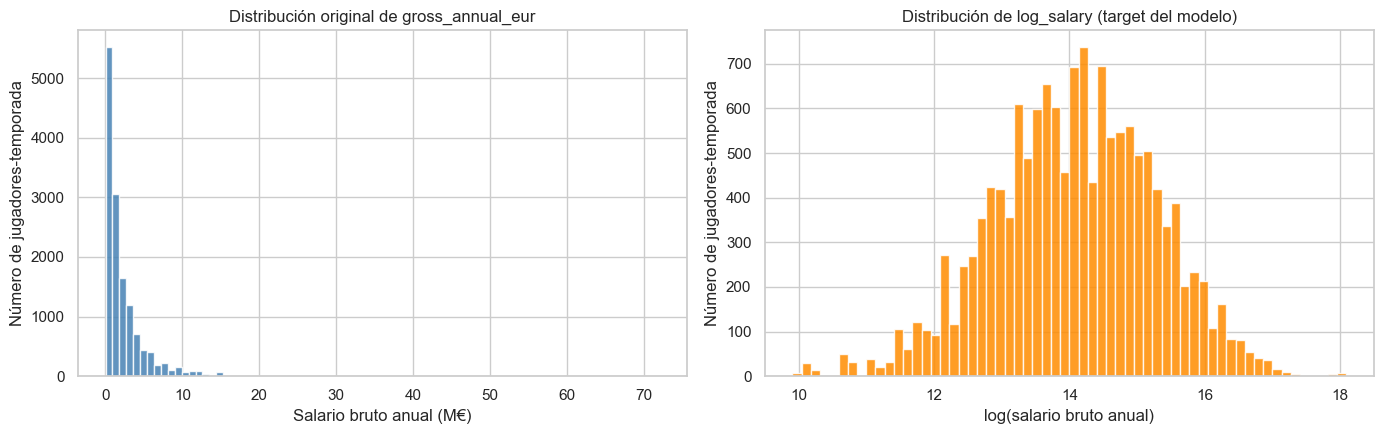

Estadísticos descriptivos del target:
count    14184.000
mean        14.059
std          1.204
min          9.903
25%         13.271
50%         14.078
75%         14.918
max         18.092
Name: log_salary, dtype: float64


In [3]:
df['log_salary'] = np.log(df['gross_annual_eur'])

# Visualización: distribución del salario antes y después de la transformación
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Antes: salario en euros (escala lineal)
ax = axes[0]
ax.hist(df['gross_annual_eur'] / 1e6, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xlabel('Salario bruto anual (M€)')
ax.set_ylabel('Número de jugadores-temporada')
ax.set_title('Distribución original de gross_annual_eur')

# Después: log_salary
ax = axes[1]
ax.hist(df['log_salary'], bins=60, color='darkorange', edgecolor='white', alpha=0.85)
ax.set_xlabel('log(salario bruto anual)')
ax.set_ylabel('Número de jugadores-temporada')
ax.set_title('Distribución de log_salary (target del modelo)')

plt.tight_layout()
plt.show()

print(f'Estadísticos descriptivos del target:')
print(df['log_salary'].describe().round(3))

## 4. Selección de features de rendimiento

En el notebook **04_04** se identificaron mediante clustering jerárquico los **bloques temáticos
naturales** del juego (Volumen/Pase, Creación, Definición, Portería, Duelos/Defensa) y se documentaron
**27 pares de variables con correlación r ≥ 0.95** (redundancia crítica).

Aquí se aplica una estrategia de **núcleo informativo amplio**: se mantienen 2-3 variables representativas
por cluster grande y se eliminan únicamente las redundancias evidentes. Este enfoque es coherente con el
uso de **modelos basados en árboles** (Random Forest, XGBoost), que toleran bien la multicolinealidad
moderada.

### Criterios de selección

1. **Eliminar pares con r ≥ 0.95**: se conserva la variable más interpretable y/o con mayor cobertura.
2. **Conservar conceptos diferenciados** dentro de cada cluster (ej: en Definición se mantienen `goals`,
   `expectedGoals` y `totalShots` porque miden cosas distintas: efectividad real, probabilidad estimada
   y volumen de intentos).
3. **Eliminar eventos extremadamente raros** (penaltis fallados al palo, autogoles, expulsiones rojas
   por doble amarilla) que aportan ruido más que señal.

### 4.1 Listas de exclusión por cluster

In [4]:
# Variables a ELIMINAR, organizadas por motivo
# Cada eliminación está justificada por correlación r >= 0.95 o por baja varianza informativa

# --- Cluster 29 (Definición) ---
drop_definicion = [
    'goalsFromInsideTheBox',  # r=0.984 con goals (la mayoría de goles son del área)
    'rightFootGoals',          # sesgo de lateralidad, no aporta sobre goals
    'shotsFromInsideTheBox',   # r=0.926 con totalShots
    'shotsOffTarget',          # r=0.938 con totalShots; tenemos totalShots y shotsOnTarget
    'goalsAssistsSum',         # r=0.926 con goals; suma artificial
]

# --- Cluster 25 (Creación) ---
drop_creacion = [
    'totalAttemptAssist',      # r=1.000 con keyPasses (son la misma variable)
    'accurateCrosses',         # r=0.961 con totalCross
]

# --- Cluster 21 (Pase posicional) ---
drop_pase = [
    'totalPasses',                  # r=0.991 con accuratePasses
    'totalOwnHalfPasses',           # r=0.998 con accurateOwnHalfPasses
    'accurateOwnHalfPasses',        # ya capturado por accuratePasses
    'totalOppositionHalfPasses',    # r=0.969 con accurateOppositionHalfPasses
    'accurateOppositionHalfPasses', # ya capturado por accurateFinalThirdPasses
]

# --- Cluster 20 (Volumen / Encajados) ---
drop_volumen = [
    'matchesStarted',           # r=0.990 con minutesPlayed
    'countRating',              # r=0.995 con appearances
    'totalRating',              # r=0.989 con appearances
    'goalsConcededInsideTheBox',# r=0.989 con goalsConceded
]

# --- Cluster 37 (Portería) ---
drop_porteria = [
    'successfulRunsOut',          # r=0.999 con runsOut
    'savedShotsFromInsideTheBox', # r=0.995 con saves
    'savedShotsFromOutsideTheBox',# r=0.983 con saves
    'savesParried',               # r=0.967 con saves
]

# --- Cluster 28 (Regate / Acción individual) ---
drop_regate = [
    'totalContest',  # r=0.964 con successfulDribbles
    'duelLost',      # capturado por groundDuelsWon/aerialLost
]

# --- Cluster 17 (Defensa de contacto) ---
drop_defensa = [
    'tacklesWon',    # r=0.975 con tackles
]

# --- Cluster 19 (Pases largos / chip) ---
drop_largos = [
    'totalLongBalls',     # r=0.960 con accurateLongBalls
    'totalChippedPasses', # r=0.965 con accurateChippedPasses
]

# --- Penaltis y eventos raros ---
drop_penaltis = [
    'penaltyGoals',           # r=0.967 con penaltiesTaken
    'attemptPenaltyMiss',     # eventos casi siempre 0
    'attemptPenaltyPost',
    'attemptPenaltyTarget',
]

drop_raros = [
    'shotFromSetPiece',
    'setPieceConversion',
    'ownGoals',
    'yellowRedCards',
    'directRedCards',  # capturado por redCards (que ya incluye directas + dobles amarillas)
]

# --- Variables agregadas redundantes ---
drop_agregadas = [
    # Ninguna adicional, ya se han ido cubriendo arriba
]

# Concatenar todas
DROP_FEATURES = (
    drop_definicion + drop_creacion + drop_pase + drop_volumen +
    drop_porteria + drop_regate + drop_defensa + drop_largos +
    drop_penaltis + drop_raros + drop_agregadas
)

print(f'Total variables a eliminar por redundancia / irrelevancia: {len(DROP_FEATURES)}')
print(f'\nDistribución por motivo:')
print(f'  · Cluster Definición:    {len(drop_definicion):2d}')
print(f'  · Cluster Creación:      {len(drop_creacion):2d}')
print(f'  · Cluster Pase:          {len(drop_pase):2d}')
print(f'  · Cluster Volumen:       {len(drop_volumen):2d}')
print(f'  · Cluster Portería:      {len(drop_porteria):2d}')
print(f'  · Cluster Regate:        {len(drop_regate):2d}')
print(f'  · Cluster Defensa:       {len(drop_defensa):2d}')
print(f'  · Cluster Pases largos:  {len(drop_largos):2d}')
print(f'  · Penaltis:              {len(drop_penaltis):2d}')
print(f'  · Eventos raros:         {len(drop_raros):2d}')

Total variables a eliminar por redundancia / irrelevancia: 34

Distribución por motivo:
  · Cluster Definición:     5
  · Cluster Creación:       2
  · Cluster Pase:           5
  · Cluster Volumen:        4
  · Cluster Portería:       4
  · Cluster Regate:         2
  · Cluster Defensa:        1
  · Cluster Pases largos:   2
  · Penaltis:               4
  · Eventos raros:          5


### 4.2 Aplicar la selección

In [5]:
# Eliminar las features descartadas
df = df.drop(columns=DROP_FEATURES)
print(f'Dataset tras eliminar redundancias: {df.shape[0]:,} filas × {df.shape[1]} columnas')

Dataset tras eliminar redundancias: 14,184 filas × 88 columnas


## 5. Tratamiento de NaN estructurales

Algunas variables (`expectedGoals`, `expectedAssists`, `ballRecovery`) tienen NaN **no aleatorios**:
Sofascore las incorporó progresivamente a su API y no están disponibles en las temporadas más antiguas.

| Variable | Disponibilidad |
|---|---|
| `expectedGoals` | Desde 22/23 (Turquía falta hasta 23/24); 23/24-25/26 completas para outfielders |
| `expectedAssists` | Mismo patrón que `expectedGoals` |
| `ballRecovery` | Desde 23/24 completas (3 temporadas de 6) |

**Estrategia adoptada:** mantener las variables (son demasiado importantes en analítica futbolística como
para descartarlas) pero **imputar NaN a 0** y crear **flags binarias** `*_available` que indican si la
métrica estaba disponible para esa observación. Esto permite a los modelos basados en árboles aprender
patrones diferenciados según la disponibilidad del dato sin introducir señal artificial vía mediana.

**Nota sobre los porteros:** los pocos NaN restantes en temporadas recientes (~360 filas) corresponden
mayoritariamente a porteros, donde `expectedGoals` y `expectedAssists` no aplican. Estos también se
imputan a 0.

In [6]:
# Diagnóstico antes de imputar
xg_xa_cols = ['expectedGoals', 'expectedAssists', 'ballRecovery']
print('=== Disponibilidad antes de imputación ===')
for c in xg_xa_cols:
    n_nan = df[c].isna().sum()
    pct   = n_nan / len(df) * 100
    print(f'  {c:25s} NaN: {n_nan:5d} ({pct:5.1f}%)')

# Crear flags y luego imputar
for c in xg_xa_cols:
    flag_name = f'{c}_available'
    df[flag_name] = df[c].notna().astype(int)
    df[c] = df[c].fillna(0)

print('\n=== Tras imputación ===')
for c in xg_xa_cols:
    print(f'  {c:25s} NaN: {df[c].isna().sum():5d}  | {c}_available media: {df[c+"_available"].mean():.3f}')

=== Disponibilidad antes de imputación ===
  expectedGoals             NaN:  5638 ( 39.7%)
  expectedAssists           NaN:  5239 ( 36.9%)
  ballRecovery              NaN:  7245 ( 51.1%)

=== Tras imputación ===
  expectedGoals             NaN:     0  | expectedGoals_available media: 0.603
  expectedAssists           NaN:     0  | expectedAssists_available media: 0.631
  ballRecovery              NaN:     0  | ballRecovery_available media: 0.489


**Variables con NaN restantes:** `outfielderBlocks` (75% NaN, sólo disponible en 25/26 para
outfielders) y `goalKicks` (3.7% NaN, principalmente outfielders donde no aplica). La primera se descarta
por inconsistencia de cobertura; la segunda se imputa a 0.

In [7]:
# outfielderBlocks: descartar (cobertura inviable)
df = df.drop(columns=['outfielderBlocks'])

# goalKicks: imputar a 0 (es una stat de portero; los outfielders sin valor tienen 0 saques)
df['goalKicks'] = df['goalKicks'].fillna(0)

# goalsPrevented: aplica solo a porteros, los outfielders tienen NaN -> imputar a 0
df['goalsPrevented'] = df['goalsPrevented'].fillna(0)

# Verificación final
print('NaN restantes en el dataset:')
nan_summary = df.isna().sum()
nan_summary = nan_summary[nan_summary > 0].sort_values(ascending=False)
if len(nan_summary) == 0:
    print('  Ninguno ✓')
else:
    print(nan_summary)

NaN restantes en el dataset:
  Ninguno ✓


## 6. Normalización per-90 minutos

En analítica futbolística, las stats acumuladas a lo largo de una temporada **no son comparables entre
jugadores con tiempos de juego muy distintos**: un delantero con 10 goles en 1.000 minutos es mucho más
prolífico que otro con 12 goles en 3.000 minutos.

La normalización **per-90 minutos** resuelve esto convirtiendo cada stat acumulable en una **tasa por
90 minutos** (la duración estándar de un partido):

$$\text{stat\_per90} = \dfrac{\text{stat\_total}}{\text{minutesPlayed}} \times 90$$

### Qué se normaliza y qué no

**SE normalizan** (stats acumulables que escalan con el tiempo de juego):
- Eventos: goles, asistencias, tiros, pases, regates, tackles, intercepciones, tarjetas...
- Cualquier contador.

**NO se normalizan** (no tiene sentido per-90):
- **Ratios y porcentajes** (`*Percentage`, `*Conversion`, `scoringFrequency`).
- **`rating`** (es una media ponderada por partido, no un contador).
- **Variables binarias o estructurales**: `totwAppearances` (no escala linealmente con minutos).
- **`minutesPlayed`** (es el denominador, sí se conserva como feature de exposición).
- **Flags** (`expectedGoals_available`, etc.).

In [8]:
# Identificar columnas que NO se normalizan a per-90
NO_PER90 = {
    # Identificadores / metadatos
    'player', 'player_id', 'team', 'team_id', 'country', 'season', 'position', 'nationality',

    # Salarios / target
    'gross_annual_eur', 'gross_weekly_eur', 'log_salary',

    # Estructurales
    'age', 'minutesPlayed',
    'rating', 'totwAppearances',

    # Porcentajes y ratios (no se per-90-zan)
    'accurateCrossesPercentage', 'accurateLongBallsPercentage', 'accuratePassesPercentage',
    'aerialDuelsWonPercentage', 'goalConversionPercentage', 'groundDuelsWonPercentage',
    'penaltyConversion', 'scoringFrequency', 'successfulDribblesPercentage',
    'tacklesWonPercentage', 'totalDuelsWonPercentage',

    # Flags de disponibilidad
    'expectedGoals_available', 'expectedAssists_available', 'ballRecovery_available',
}

# El resto de stats numéricas son candidatas a per-90
all_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
to_per90    = [c for c in all_numeric if c not in NO_PER90]

print(f'Variables que NO se normalizan: {len(NO_PER90 & set(df.columns))}')
print(f'Variables que se convierten a per-90: {len(to_per90)}')

Variables que NO se normalizan: 29
Variables que se convierten a per-90: 61


In [9]:
# Aplicar la normalización per-90
# Renombramos las variables a *_per90 para dejar claro qué representan

# Evitamos división por cero (aunque tras filtro >=450min no debería haber)
mins = df['minutesPlayed'].replace(0, np.nan)

for col in to_per90:
    new_col = f'{col}_per90'
    df[new_col] = df[col] / mins * 90

# Eliminamos las versiones absolutas (ya tenemos las per-90)
df = df.drop(columns=to_per90)

# Verificación: que no haya NaN/inf raros tras la división
inf_count = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
nan_count = df.select_dtypes(include=[np.number]).isna().sum().sum()
print(f'Inf tras per-90: {inf_count}')
print(f'NaN tras per-90: {nan_count}')

# Mostrar shape
print(f'\nDataset tras per-90: {df.shape[0]:,} filas × {df.shape[1]} columnas')

Inf tras per-90: 0
NaN tras per-90: 0

Dataset tras per-90: 14,184 filas × 90 columnas


## 7. Features estructurales: edad y curva de Mincer

La relación entre **edad y salario** en deporte profesional sigue un patrón cóncavo bien documentado:
los salarios crecen con la edad hasta la **edad pico** (~27-30 años en fútbol) y luego decrecen. Para
permitir al modelo capturar esta curvatura se añade:

$$\text{age}^2 = \text{age} \times \text{age}$$

Esta es una técnica clásica del **modelo de Mincer** (Becker, 1964; Mincer, 1974) usada en economía
laboral para estimar ecuaciones de salario.

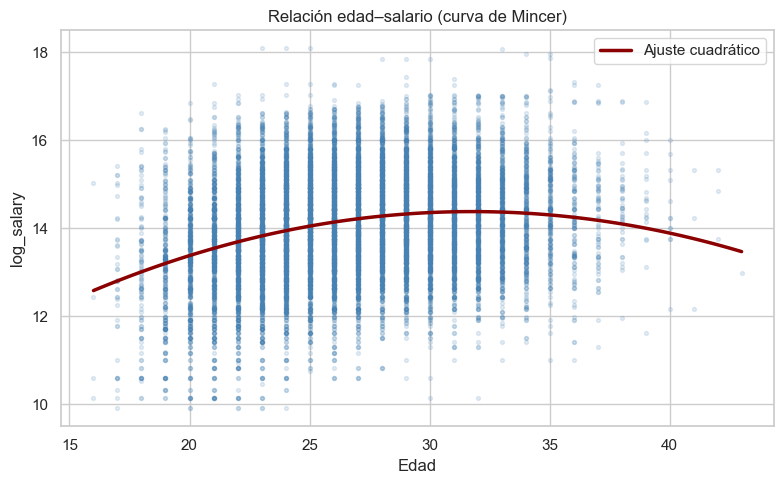

Edad-pico estimada (vértice de la parábola): 31.8 años


In [10]:
df['age_squared'] = df['age'] ** 2

# Visualización rápida de la relación edad - salario
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['age'], df['log_salary'], alpha=0.15, s=8, color='steelblue')

# Línea de ajuste cuadrática
ages_grid = np.linspace(df['age'].min(), df['age'].max(), 100)
coeffs    = np.polyfit(df['age'], df['log_salary'], deg=2)
ax.plot(ages_grid, np.polyval(coeffs, ages_grid), color='darkred', lw=2.5, label='Ajuste cuadrático')

ax.set_xlabel('Edad')
ax.set_ylabel('log_salary')
ax.set_title('Relación edad–salario (curva de Mincer)')
ax.legend()
plt.tight_layout()
plt.show()

# Edad-pico estimada
edad_pico = -coeffs[1] / (2 * coeffs[0])
print(f'Edad-pico estimada (vértice de la parábola): {edad_pico:.1f} años')

## 8. Encoding de variables categóricas

Las variables categóricas se codifican con **one-hot encoding**, que crea una columna binaria por cada
valor posible. Esto permite a los modelos tratar cada categoría como independiente sin imponer un orden
artificial.

### Variables a codificar

| Variable | Categorías | Estrategia |
|---|---:|---|
| `position` | 4 (D, M, F, K) | One-hot directo |
| `country` | 6 (ligas) | One-hot directo |
| `season` | 6 | One-hot directo |
| `nationality` | ~140 | Top-15 + "Otras" → one-hot |

### 8.1 `nationality`: descartada como feature

Inicialmente se consideró la nacionalidad como variable predictora, pero un análisis posterior mostró que
**actúa como proxy de la liga y no aporta información propia**: los jugadores de nacionalidad turca, por
ejemplo, presentan un salario medio bajo (~0.6 M€), pero esto se debe a que el 93% juega en la Süper Lig
(la liga peor pagada); los turcos que juegan en las otras cinco ligas cobran ~2.6 M€, en línea con la
media global. Es decir, el efecto salarial lo explica la **liga** (`country`), no la nacionalidad.

Mantener la nacionalidad introduciría una **correlación espuria** (el modelo aprendería atajos del tipo
"nacionalidad → salario" que en realidad son "liga → salario", ya capturados por `country`), con un aporte
marginal al R² (~0.008) y riesgo de sobreajuste. Por ello se **descarta** como feature.

In [11]:
# La nacionalidad se descarta como feature (ver justificación arriba): actúa como proxy de la liga.
# Se elimina la columna para que no entre en el dataset de modelado.
if 'nationality' in df.columns:
    df = df.drop(columns=['nationality'])
    print("Columna 'nationality' descartada del dataset de features.")
else:
    print("La columna 'nationality' ya no está presente.")

Columna 'nationality' descartada del dataset de features.


### 8.2 Aplicar one-hot encoding

Para evitar **multicolinealidad perfecta** (la suma de las columnas dummy de cada categórica es siempre 1, lo que crea una dependencia lineal exacta), se elimina una **categoría de referencia** por variable. Los coeficientes de las restantes se interpretan como diferencia respecto a la categoría omitida ("baseline").

Esto es crítico para modelos lineales (Ridge, Lasso, OLS) donde la matriz de diseño debe tener rango completo. Para modelos de árboles (RF, XGBoost) no causa problema, pero la decisión es global y consistente.

In [12]:
# Variables a codificar y categoría de referencia (baseline) que se omitirá en el one-hot.
# La elección de baseline afecta la interpretación de coeficientes en modelos lineales:
#   · position_M     → mediocampistas (categoría más numerosa, posición "neutra" del campo)
#   · country_turkey → liga económicamente más débil (los coefs de las otras = premium sobre Turquía)
#   · season_2021    → primera temporada (los coefs de las otras = inflación acumulada)
BASELINES = {
    'position':        'M',
    'country':         'turkey',
    'season':          '2021',
}

# One-hot manteniendo todas las categorías; luego eliminamos la baseline
df_encoded = pd.get_dummies(df, columns=list(BASELINES.keys()), prefix=list(BASELINES.keys()), drop_first=False)

# Eliminar columnas baseline
drop_baseline_cols = [f'{var}_{val}' for var, val in BASELINES.items()]
df_encoded = df_encoded.drop(columns=drop_baseline_cols)
print(f'Baselines eliminadas: {drop_baseline_cols}')

# pd.get_dummies devuelve booleanos por defecto en pandas reciente; convertimos a int
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(f'\nColumnas antes del encoding:  {df.shape[1]}')
print(f'Columnas tras el encoding:    {df_encoded.shape[1]}')

df = df_encoded

Baselines eliminadas: ['position_M', 'country_turkey', 'season_2021']

Columnas antes del encoding:  90
Columnas tras el encoding:    100


## 9. Limpieza final del dataset

Se eliminan las columnas que **no son útiles para el modelo**:

- **Identificadores**: `player`, `player_id`, `team`, `team_id` (no son features informativas; se
  conservaría `player_id` solo si se quisiera hacer trazabilidad post-modelo, pero el target ya está
  vinculado a la fila).
- **Variable original `nationality`**: ya está codificada en `nationality_grp_*`.
- **`gross_weekly_eur`**: redundante con `gross_annual_eur`.

Se conservan **`gross_annual_eur` y `log_salary`** (target en escala original y logarítmica) para que
el notebook de modelado pueda elegir cuál usar y para poder reportar métricas en euros.

In [13]:
# Para trazabilidad mantenemos player_id, player, team, country (en categórica original) - opcional
# Pero para el dataset de entrada al modelo los quitamos

# Identificadores no informativos para el modelo
DROP_IDS = ['player', 'player_id', 'team', 'team_id', 'nationality', 'gross_weekly_eur']

df_final = df.drop(columns=[c for c in DROP_IDS if c in df.columns])

print(f'Dataset final: {df_final.shape[0]:,} filas × {df_final.shape[1]} columnas')

Dataset final: 14,184 filas × 95 columnas


## 10. Validación final

Antes de guardar, se realizan comprobaciones:

1. No quedan NaN en ninguna columna.
2. No hay valores infinitos.
3. El target (`log_salary`) está bien definido para todas las filas.
4. Resumen del shape y composición de features.

In [14]:
# 1. NaN
nan_total = df_final.isna().sum().sum()
print(f'NaN totales: {nan_total}')
if nan_total > 0:
    print('Columnas con NaN:')
    print(df_final.isna().sum()[df_final.isna().sum() > 0])

# 2. Infinitos
inf_total = np.isinf(df_final.select_dtypes(include=[np.number])).sum().sum()
print(f'Valores infinitos: {inf_total}')

# 3. Target
print(f'Target log_salary: {df_final["log_salary"].notna().sum():,} válidos / {len(df_final):,} filas')

# 4. Composición
print(f'\nComposición del dataset final:')
print(f'  · Filas (jugador-temporada):  {df_final.shape[0]:,}')
print(f'  · Columnas totales:           {df_final.shape[1]}')

# Desglose por tipo
n_per90    = sum(1 for c in df_final.columns if c.endswith('_per90'))
n_position = sum(1 for c in df_final.columns if c.startswith('position_'))
n_country  = sum(1 for c in df_final.columns if c.startswith('country_'))
n_season   = sum(1 for c in df_final.columns if c.startswith('season_'))
n_flags    = sum(1 for c in df_final.columns if c.endswith('_available'))

print(f'\n  Desglose:')
print(f'  · Stats per-90:               {n_per90}')
print(f'  · One-hot position:           {n_position}')
print(f'  · One-hot country:            {n_country}')
print(f'  · One-hot season:             {n_season}')
print(f'  · Flags disponibilidad:       {n_flags}')
print(f'  · Otras (target, age, age², %, rating...): {df_final.shape[1] - n_per90 - n_position - n_country - n_season - n_flags}')

NaN totales: 0
Valores infinitos: 0
Target log_salary: 14,184 válidos / 14,184 filas

Composición del dataset final:
  · Filas (jugador-temporada):  14,184
  · Columnas totales:           95

  Desglose:
  · Stats per-90:               61
  · One-hot position:           3
  · One-hot country:            5
  · One-hot season:             5
  · Flags disponibilidad:       3
  · Otras (target, age, age², %, rating...): 18


## 11. Guardado

In [15]:
df_final.to_csv(OUT_PATH, index=False)
size_mb = OUT_PATH.stat().st_size / (1024**2)
print(f'✓ Guardado: {OUT_PATH}')
print(f'  Tamaño: {size_mb:.2f} MB')
print(f'  Shape:  {df_final.shape}')

✓ Guardado: d:\USER\Desktop\TFM\data\modeling\regression\regresion_dataset.csv
  Tamaño: 12.67 MB
  Shape:  (14184, 95)


## 12. Resumen del notebook

### Transformaciones aplicadas

1. **Filtro del target**: 14.202 → ~14.184 filas (las que tienen salario disponible).
2. **Target**: `log_salary = log(gross_annual_eur)` para corregir el sesgo a la derecha.
3. **Selección de features**: ~28 stats eliminadas por redundancia (clusters del 04_04) o eventos raros.
4. **NaN estructurales**: imputación a 0 + flags `*_available` para `expectedGoals`, `expectedAssists`,
   `ballRecovery`. Se descarta `outfielderBlocks` por cobertura inviable.
5. **Per-90**: ~75 stats acumulables convertidas a tasa por 90 minutos. Ratios, porcentajes y rating
   se mantienen sin transformar.
6. **Edad**: se conserva `age` y se añade `age_squared` (modelo de Mincer).
7. **Categóricas**: one-hot de `position`, `country`, `season`, `nationality_grp` (top-15 + Otras), eliminando una baseline por variable (`M`, `turkey`, `2021`, `Otras`) para evitar multicolinealidad perfecta.

### Output

`data/modeling/regression/regresion_dataset.csv` — dataset listo para entrenar modelos de regresión salarial.

### Próximos pasos (05_03 / 06)

- Análisis exploratorio sobre el dataset de regresión: distribuciones por posición, validación de la
  relación edad–salario, coherencia de features per-90.
- Split temporal: train (20/21–23/24), val (24/25), test (25/26).
- Modelos baseline (regresión lineal, Ridge/Lasso) y modelos de árboles (RF, XGBoost) con grid search.
- Análisis de residuos: detectar jugadores sobrevalorados / infravalorados.